# Vectorized micrograd — Spiral Classification Demo

A vectorized autograd engine in the spirit of Karpathy's micrograd.  
Each `Value` holds a NumPy array instead of a scalar, so a dense layer is
a single matmul node rather than thousands of scalar nodes.


## Engine at a glance

`vector_engine.py` keeps the same interface as the original micrograd `Value`
— `backward()`, `relu()`, operator overloads — but every node stores a full
NumPy array. The two pieces that make this non-trivial are:

* **`_unbroadcast`** — sums a broadcasted gradient back to the operand shape.
* **`__matmul__`** — explicit 2D backward (`dL/dX = dL/dY @ W.T`, `dL/dW = X.T @ dL/dY`).

Everything else (add, mul, pow, relu, tanh, log, sum, mean) follows the same
pattern as the scalar engine.


## Building the MLP

`vector_nn.py` has two classes:

* **`Layer`** — wraps a weight matrix `W` (nin × nout) and bias `b` (nout,).  
  He initialisation: `W ~ N(0, sqrt(2/nin))`.
* **`MLP`** — stacks layers, applies the chosen activation between hidden layers,
  leaves the last layer linear.

The `activation` argument (new in this version) defaults to `Value.relu` but
accepts any callable, e.g. `Value.tanh`.


In [1]:
from vect_micrograd.vect_nn import MLP

model = MLP(2, [32, 32, 3])          # 2-in, two hidden, 3-class output
print(model)
print(f"Total parameters: {sum(p.data.size for p in model.parameters()):,}")


MLP of [Layer(2, 32), Layer(32, 32), Layer(32, 3)]
Total parameters: 1,251


## Spiral data

Three interleaved spirals — a classic non-linearly separable benchmark.


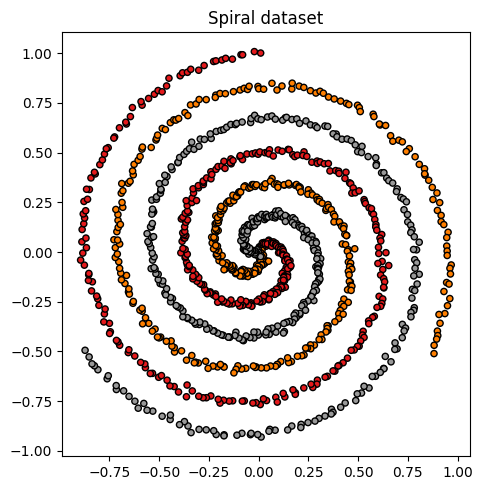

X: (1200, 2), y: (1200,)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def make_spiral(n=100, classes=3, noise=0.1, seed=42):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for c in range(classes):
        t = np.linspace(0, 1, n)
        angle = t * 4 * np.pi + (2 * np.pi * c / classes)
        r = t
        X.append(np.column_stack([r * np.sin(angle), r * np.cos(angle)]))
        y.append(np.full(n, c))
    X = np.vstack(X) + rng.standard_normal((n * classes, 2)) * noise
    y = np.concatenate(y)
    return X.astype(float), y.astype(int)

X, y = make_spiral(n=400, classes=3, noise=0.01)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='k', s=20)
ax.set_title("Spiral dataset")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
print(f"X: {X.shape}, y: {y.shape}")


## Training

In [3]:
from vect_micrograd.optim import SGD
from vect_micrograd.utils import one_hot

np.random.seed(0) # re-initialise so results are reproducible

model = MLP(2, [16, 16, 3])
Y = one_hot(y, classes=3)

optimizer = SGD(model.parameters(), lr=1.0, total_steps=3000)

losses, accs = [], []

for k in range(3000):
    logits = model(X)
    loss, probs = logits.softmax_ce(Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step(k)

    losses.append(loss.item())
    accs.append((probs.argmax(axis=1) == y).mean())

    if k % 50 == 0:
        print(f"step {k:3d}  loss {loss.item():.4f}  acc {accs[-1]:.2%}")


step   0  loss 1.1475  acc 32.75%
step  50  loss 1.0648  acc 47.25%
step 100  loss 1.0407  acc 50.67%
step 150  loss 1.0237  acc 44.17%
step 200  loss 1.0361  acc 44.67%
step 250  loss 0.9845  acc 43.08%
step 300  loss 0.9646  acc 49.75%
step 350  loss 0.9454  acc 54.25%
step 400  loss 0.9411  acc 50.92%
step 450  loss 0.9109  acc 55.00%
step 500  loss 0.8546  acc 57.83%
step 550  loss 0.8384  acc 60.25%
step 600  loss 0.9539  acc 54.75%
step 650  loss 0.8366  acc 59.42%
step 700  loss 0.8396  acc 56.83%
step 750  loss 0.7324  acc 60.92%
step 800  loss 0.7162  acc 64.83%
step 850  loss 1.0550  acc 49.92%
step 900  loss 0.5864  acc 78.33%
step 950  loss 0.8254  acc 61.83%
step 1000  loss 0.5529  acc 78.25%
step 1050  loss 0.5306  acc 77.08%
step 1100  loss 0.5115  acc 79.92%
step 1150  loss 0.6956  acc 64.25%
step 1200  loss 0.4876  acc 79.67%
step 1250  loss 0.4386  acc 84.67%
step 1300  loss 0.4511  acc 83.50%
step 1350  loss 0.3952  acc 86.25%
step 1400  loss 0.3551  acc 88.25%
step 

## Results


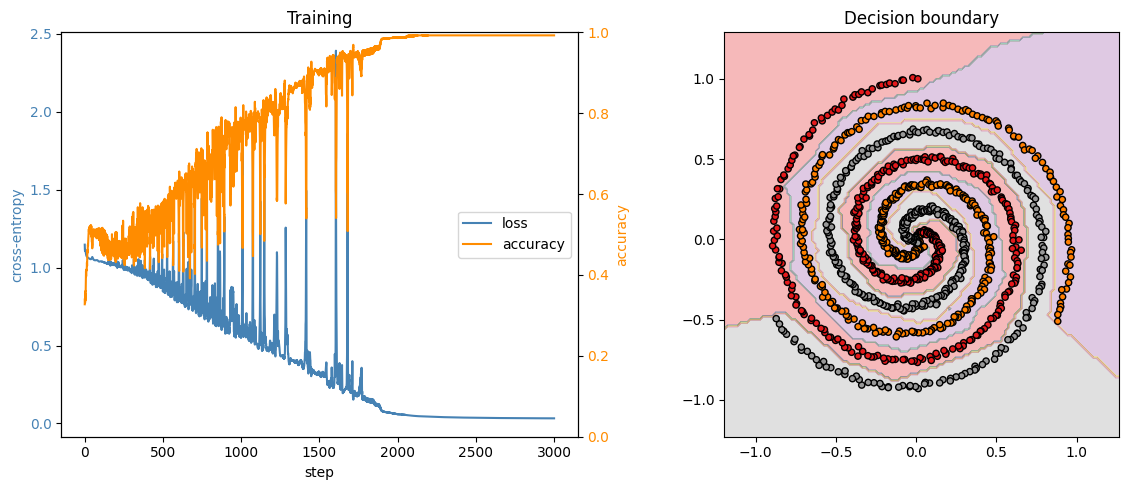

Final loss: 0.0326  Final acc: 99.25%


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- loss + accuracy on twin axes ---
ax1.plot(losses, color='steelblue', label='loss')
ax1.set_xlabel("step")
ax1.set_ylabel("cross-entropy", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax_acc = ax1.twinx()
ax_acc.plot(accs, color='darkorange', label='accuracy')
ax_acc.set_ylabel("accuracy", color='darkorange')
ax_acc.tick_params(axis='y', labelcolor='darkorange')
ax_acc.set_ylim(0, 1)

lines = ax1.get_lines() + ax_acc.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right')
ax1.set_title("Training")

# --- decision boundary ---
h = 0.02
x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))
grid = np.column_stack([xx.ravel(), yy.ravel()])
preds = model(grid).data.argmax(axis=1).reshape(xx.shape)

ax2.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.Set1)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='k', s=20)
ax2.set_title("Decision boundary")
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.4f}  Final acc: {accs[-1]:.2%}")
